In [ ]:
import os
import sys

os.chdir("/content")
!rm -rf chronos-forecasting
!git clone https://github.com/amazon-science/chronos-forecasting.git
!pip install gluonts datasets accelerate transformers matplotlib pandas scikit-learn pyyaml -q

Cloning into 'chronos-forecasting'...
remote: Enumerating objects: 1030, done.
remote: Counting objects: 100% (560/560), done.
remote: Compressing objects: 100% (241/241), done.
remote: Total 1030 (delta 444), reused 319 (delta 319), pack-reused 470 (from 2)
Receiving objects: 100% (1030/1030), 2.29 MiB | 7.01 MiB/s, done.
Resolving deltas: 100% (508/508), done.


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import tempfile
import glob
import json
import subprocess
from chronos import ChronosPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [ ]:
from gluonts.dataset.arrow import ArrowWriter

url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv"
df = pd.read_csv(url)

series_ids = ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10']
print(f"Using {len(series_ids)} series")

Using 10 series


In [ ]:
context_length = 512
prediction_length = 48

train_data_list = []
for series_id in series_ids:
    series_data = df[df['item_id'] == series_id]['target'].values
    total_length = len(series_data)
    train_length = total_length - prediction_length - 100
    if train_length > context_length:
        train_series = series_data[:train_length]
        train_data_list.append({
            "start": "1750-01-01 00:00:00",
            "target": train_series.tolist()
        })
        print(f"{series_id}: {len(train_series)} points")

print(f"\nTotal series: {len(train_data_list)}")

H1: 552 points
H2: 552 points
H3: 552 points
H4: 552 points
H5: 552 points
H6: 552 points
H7: 552 points
H8: 552 points
H9: 552 points
H10: 552 points

Total series: 10


In [ ]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.float32,
)

test_series = df[df['item_id'] == 'H1']['target'].values
context_test = torch.tensor(test_series[-context_length - prediction_length:-prediction_length], dtype=torch.float32)
actual_test = test_series[-prediction_length:]

forecast_zs = pipeline.predict(
    context_test,
    prediction_length=prediction_length,
    num_samples=20,
    temperature=1.0,
    top_k=50,
    top_p=0.95,
)

forecast_np_zs = forecast_zs.numpy()
if forecast_np_zs.ndim == 3 and forecast_np_zs.shape[0] == 1:
    forecast_np_zs = forecast_np_zs[0]

median_zs = np.median(forecast_np_zs, axis=0)

In [ ]:
def weighted_quantile_loss(actual, forecast_samples, quantile_levels=[0.1, 0.5, 0.9]):
    losses = []
    for q_level in quantile_levels:
        pred_q = np.quantile(forecast_samples, q_level, axis=0)
        errors = actual - pred_q
        if q_level < 0.5:
            weight = 2.0 * q_level
        elif q_level > 0.5:
            weight = 2.0 * (1.0 - q_level)
        else:
            weight = 1.0
        losses.append(np.mean(weight * np.abs(errors)))
    return np.mean(losses)

mae_zs = mean_absolute_error(actual_test, median_zs)
smape_zs = 100 * np.mean(2 * np.abs(actual_test - median_zs) / (np.abs(actual_test) + np.abs(median_zs) + 1e-8))
wql_zs = weighted_quantile_loss(actual_test, forecast_np_zs)

print(f"Zero-Shot MAE: {mae_zs:.3f}, sMAPE: {smape_zs:.2f}%, WQL: {wql_zs:.4f}")

Zero-Shot MAE: 22.116, sMAPE: 3.18%, WQL: 11.5152


In [ ]:
with tempfile.TemporaryDirectory() as tmpdir:
    train_path = os.path.join(tmpdir, "train.arrow")
    writer = ArrowWriter(compression="lz4")
    writer.write_to_file(train_data_list, path=train_path)

    os.makedirs("./finetuned_model", exist_ok=True)

    train_script = "/content/chronos-forecasting/scripts/training/train.py"
    train_paths_str = json.dumps([train_path])

    train_cmd = f"""
python {train_script} \
    '{train_paths_str}' \
    --model-id amazon/chronos-t5-small \
    --no-random-init \
    --max-steps 1000 \
    --learning-rate 1e-5 \
    --per-device-train-batch-size 8 \
    --context-length {context_length} \
    --prediction-length {prediction_length} \
    --output-dir ./finetuned_model \
    --save-steps 500
"""

    print("Training")
    result = subprocess.run(train_cmd, shell=True, capture_output=True, text=True)
    print(result.stdout)
    if result.stderr:
        print("Errors:", result.stderr)

Training
{'loss': 2.024, 'grad_norm': 1.2474104166030884, 'learning_rate': 5.01e-06, 'epoch': 0.5}
{'loss': 1.9089, 'grad_norm': 1.1465067863464355, 'learning_rate': 1e-08, 'epoch': 1.0}
{'train_runtime': 702.2393, 'train_samples_per_second': 22.784, 'train_steps_per_second': 1.424, 'train_loss': 1.9664407958984376, 'epoch': 1.0}

Errors: INFO:/content/chronos-forecasting/scripts/training/train.py:TF32 format is only available on devices with compute capability >= 8. Setting tf32 to False.
INFO:/content/chronos-forecasting/scripts/training/train.py:Using SEED: 1308222091
INFO:/content/chronos-forecasting/scripts/training/train.py:Logging dir: finetuned_model/run-0
INFO:/content/chronos-forecasting/scripts/training/train.py:Loading and filtering 1 datasets for training: ['/tmp/tmp5hqv1m2m/train.arrow']
INFO:/content/chronos-forecasting/scripts/training/train.py:Mixing probabilities: [1.0]
INFO:/content/chronos-forecasting/scripts/training/train.py:Initializing model
INFO:/content/chrono

In [ ]:
checkpoint_dirs = glob.glob("./finetuned_model/run-*/checkpoint-*")
if checkpoint_dirs:
    latest_checkpoint = max(checkpoint_dirs, key=lambda x: int(x.split('-')[-1]) if x.split('-')[-1].isdigit() else 0)
    print(f"Loading from {latest_checkpoint}")

    pipeline_ft = ChronosPipeline.from_pretrained(latest_checkpoint, device_map=device)

    forecast_ft = pipeline_ft.predict(
        context_test,
        prediction_length=prediction_length,
        num_samples=20,
        temperature=1.0,
        top_k=50,
        top_p=0.95,
    )

    forecast_np_ft = forecast_ft.numpy()
    if forecast_np_ft.ndim == 3 and forecast_np_ft.shape[0] == 1:
        forecast_np_ft = forecast_np_ft[0]

    median_ft = np.median(forecast_np_ft, axis=0)
    lower_ft = np.percentile(forecast_np_ft, 10, axis=0)
    upper_ft = np.percentile(forecast_np_ft, 90, axis=0)

    mae_ft = mean_absolute_error(actual_test, median_ft)
    smape_ft = 100 * np.mean(2 * np.abs(actual_test - median_ft) / (np.abs(actual_test) + np.abs(median_ft) + 1e-8))
    wql_ft = weighted_quantile_loss(actual_test, forecast_np_ft)

    print("\n" + "="*50)
    print("Fine-Tuned Results")
    print("="*50)
    print(f"MAE: {mae_ft:.3f}, sMAPE: {smape_ft:.2f}%, WQL: {wql_ft:.4f}")

    print("\n" + "="*50)
    print("Comparison")
    print("="*50)
    print(f"Metric     Zero-Shot    Fine-Tuned   Improvement")
    print(f"MAE        {mae_zs:.3f}        {mae_ft:.3f}        {(mae_zs-mae_ft)/mae_zs*100:.1f}%")
    print(f"sMAPE      {smape_zs:.2f}%       {smape_ft:.2f}%       {(smape_zs-smape_ft)/smape_zs*100:.1f}%")
    print(f"WQL        {wql_zs:.4f}       {wql_ft:.4f}       {(wql_zs-wql_ft)/wql_zs*100:.1f}%")
    print("="*50)

`generation_config` default values have been modified to match model-specific defaults: {'decoder_start_token_id': 0}. If this is not desired, please set these values explicitly.


Loading from ./finetuned_model/run-0/checkpoint-1000

Fine-Tuned Results
MAE: 22.359, sMAPE: 3.13%, WQL: 11.8068

Comparison
Metric     Zero-Shot    Fine-Tuned   Improvement
MAE        22.116        22.359        -1.1%
sMAPE      3.18%       3.13%       1.6%
WQL        11.5152       11.8068       -2.5%


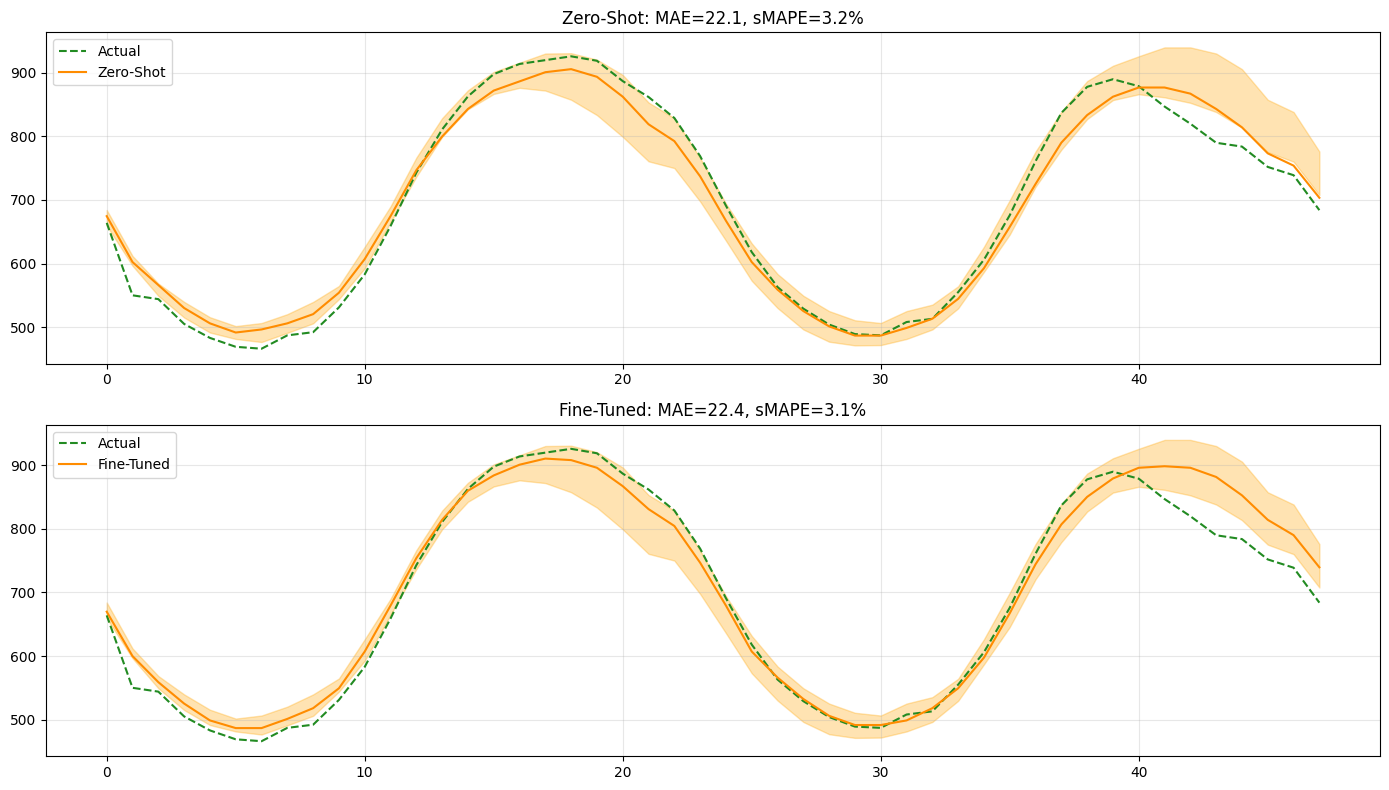

In [ ]:
time_hours = np.arange(prediction_length)

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(time_hours, actual_test, label="Actual", color="forestgreen", linewidth=1.5, linestyle="--")
plt.plot(time_hours, median_zs, label="Zero-Shot", color="darkorange", linewidth=1.5)
plt.fill_between(time_hours, lower_ft, upper_ft, color="orange", alpha=0.3)
plt.title(f"Zero-Shot: MAE={mae_zs:.1f}, sMAPE={smape_zs:.1f}%")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(time_hours, actual_test, label="Actual", color="forestgreen", linewidth=1.5, linestyle="--")
plt.plot(time_hours, median_ft, label="Fine-Tuned", color="darkorange", linewidth=1.5)
plt.fill_between(time_hours, lower_ft, upper_ft, color="orange", alpha=0.3)
plt.title(f"Fine-Tuned: MAE={mae_ft:.1f}, sMAPE={smape_ft:.1f}%")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparison.png", dpi=150)
plt.show()